# Importation des packages

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pickle 
import scipy.stats as st

# Définition des fonctions

### Fonction pour agréger une métrique

In [2]:
def collect_metrics_all_folds(results, metric_name, class_name="Gonade"):
    dice = []
    for fold_name, fold_results in results.items():
        if fold_name == "fold_times":
            continue
        if isinstance(fold_results, dict):
            dice.extend(fold_results[metric_name][class_name])
        else:
            dice.extend(image_results["metrics"][class_name][metric_name] for image_results in fold_results)
    return dice

def collect_all_folds(results, name):
    categories = []
    for fold_name, fold_results in results.items():
        if fold_name == "fold_times":
            continue
        if isinstance(fold_results, dict):
            categories.extend(fold_results[name])
        else:
            categories.extend(image_results["metrics"][name] for image_results in fold_results)
    return categories

### Fonction pour visualiser et comparer des boxplots

In [3]:
def plot_boxplot(datasets, labels, colors, size=(6, 4), limite_echelle=np.arange(0, 1.01, 0.05)):
    n = len(datasets)
    fig, axes = plt.subplots(1, n, figsize=size)

    # Si un seul graphique, axes n'est pas une liste
    if n == 1:
        axes = [axes]

    for i, ax in enumerate(axes):

        # Création du boxplot
        boxplot = ax.boxplot(datasets[i], patch_artist=True)

        # Labels
        ax.set_xticks(range(1, len(labels[i]) + 1))
        ax.set_xticklabels(labels[i])

        # Couleurs
        for patch, color in zip(boxplot["boxes"], colors):
            patch.set_facecolor(color)
            patch.set_alpha(0.4)
            patch.set_edgecolor(color)

        # Médianes
        for median in boxplot["medians"]:
            median.set_color("black")
            median.set_linewidth(1.5)

        # Grille
        ax.grid(True, linestyle="--", alpha=0.6, axis="y")

        # Échelle
        ax.set_yticks(limite_echelle)
        ax.set_ylim(limite_echelle[0], limite_echelle[-1])

    plt.tight_layout()
    plt.show()


# Visualisation et comparaison des résultats des différents modèles : validation

## Importation des différents modèles

### U-NET models

In [4]:
# ======= CAVITE =======
# U-Net 3 classes
with open('../UNet/saves/Global/results_UNet_3classes.pkl', 'rb') as f:
    results_UNET_3classes = pickle.load(f)

# U-Net 3 classes TEST
#with open('../UNet/saves/Global/results_UNet_3classes_test.pkl', 'rb') as f:
    #results_UNET_3classes_test = pickle.load(f)

# U-Net 2 classes
with open('../UNet/saves/Global/results_UNet_2classes.pkl', 'rb') as f:
    results_UNET_2classes = pickle.load(f)

# AttentionUNet++ 2 classes
with open('../UNet/saves/Global/results_AttentionUNet++_2classes.pkl', 'rb') as f:
    results_AttentionUNet_2classes = pickle.load(f)

# CSA-Net 3 classes
with open('../UNet/saves/Global/results_CSANet_3classes.pkl', 'rb') as f:
    results_CSANet_3classes = pickle.load(f)


# ======= OEUFS =======
# U-Net oeufs
with open('../UNet/saves/Global/results_UNet_oeufs.pkl', 'rb') as f:
    results_UNET_oeufs= pickle.load(f)

# U-Net oeufs
with open('../UNet/saves/Global/results_UNet_oeufs_contour.pkl', 'rb') as f:
    results_UNET_oeufs_contour= pickle.load(f)

# CSANET
with open('../UNet/saves/Global/results_EggSegmentationHVUNet_oeufs.pkl', 'rb') as f:
    results_SegHV_oeufs = pickle.load(f)

### YOLO models

In [5]:
# YOLO avec Data Augmentation, loss par défaut
with open('../YOLO26/saves/results_YOLO_instance_3classes.pkl', 'rb') as fp:
    results_YOLO_instance_3classes = pickle.load(fp)

# YOLO sans Data Augmentation, loss par défaut
with open('../YOLO26/saves/results_YOLO_instance_oeufs.pkl', 'rb') as fp:
    results_YOLO_instance_oeufs = pickle.load(fp)

# YOLO avec Data Augmentation, loss modifiée
with open('../YOLO26/saves/results_YOLO_semantique_3classes.pkl', 'rb') as fp:
    results_DA_YOLO_semantique_3classes = pickle.load(fp)

## Comparaisons globales des modèles

In [6]:
names_gonade = collect_all_folds(results_UNET_3classes, "name")
names_oeufs = collect_all_folds(results_UNET_oeufs, "name")

### Récupération des Dice

In [7]:
# Cavite
DICE_UNET_3classes_Gonade = collect_metrics_all_folds(results_UNET_3classes, class_name="Gonade", metric_name="dice_by_class")
#DICE_UNET_3classes_test_Gonade = collect_metrics_all_folds(results_UNET_3classes_test, class_name="Gonade", metric_name="dice_by_class")
DICE_YOLO_instance_3classes_Gonade = collect_metrics_all_folds(results_YOLO_instance_3classes, class_name="Gonade", metric_name = "dice")
DICE_YOLO_semantique_3classes_Gonade = collect_metrics_all_folds(results_DA_YOLO_semantique_3classes, class_name="Gonade", metric_name = "dice")
DICE_UNET_2classes_Gonade = collect_metrics_all_folds(results_UNET_2classes, class_name="Gonade", metric_name="dice_by_class")
DICE_ATTENTION_UNET_2classes_Gonade = collect_metrics_all_folds(results_AttentionUNet_2classes, class_name="Gonade", metric_name="dice_by_class")
DICE_CSANet_3classes_Gonade = collect_metrics_all_folds(results_CSANet_3classes, class_name="Gonade", metric_name="dice_by_class")

# Oeufs
DICE_UNET_oeufs = collect_metrics_all_folds(results_UNET_oeufs, class_name="Oeuf", metric_name="dice_by_class")
DICE_UNET_oeufs_contour = collect_metrics_all_folds(results_UNET_oeufs_contour, class_name="Oeuf", metric_name="dice_by_class")
DICE_SegHV_oeufs = collect_metrics_all_folds(results_SegHV_oeufs, class_name="Oeuf", metric_name="dice_by_class")
DICE_YOLO_instance_oeufs = collect_metrics_all_folds(results_YOLO_instance_oeufs, class_name="Oeuf", metric_name="dice")

### Récupération de la différence de surface

In [10]:
# Cavite
Diff_UNET_3classes = collect_metrics_all_folds(results_UNET_3classes, class_name="Gonade", metric_name="diff_surface")
#diff_UNET_3classes_test = collect_metrics_all_folds(results_UNET_3classes_test, class_name="Gonade", metric_name="diff_surface")
Diff_YOLO_instance_3classes = collect_metrics_all_folds(results_YOLO_instance_3classes, class_name="Gonade", metric_name="diff_surface")
Diff_YOLO_semantique_3classes = collect_metrics_all_folds(results_DA_YOLO_semantique_3classes, class_name="Gonade", metric_name="diff_surface")
Diff_UNET_2classes = collect_metrics_all_folds(results_UNET_2classes, class_name="Gonade", metric_name="diff_surface")
Diff_ATTENTION_UNET_2classes = collect_metrics_all_folds(results_AttentionUNet_2classes, class_name="Gonade", metric_name="diff_surface")
Diff_CSANet_3classes = collect_metrics_all_folds(results_CSANet_3classes, class_name="Gonade", metric_name="diff_surface")

# oeufs
Diff_UNET_oeufs = collect_metrics_all_folds(results_UNET_oeufs, class_name="Oeuf", metric_name="diff_surface")
Diff_UNET_oeufs_contour = collect_metrics_all_folds(results_UNET_oeufs_contour, class_name="Oeuf", metric_name="diff_surf")
Diff_SegHV_oeufs = collect_metrics_all_folds(results_SegHV_oeufs, class_name="Oeuf", metric_name="diff_surface")
Diff_YOLO_instance_oeufs = collect_metrics_all_folds(results_YOLO_instance_oeufs, class_name="Oeuf", metric_name="diff_surface")

### Boxplots Dice des gonades

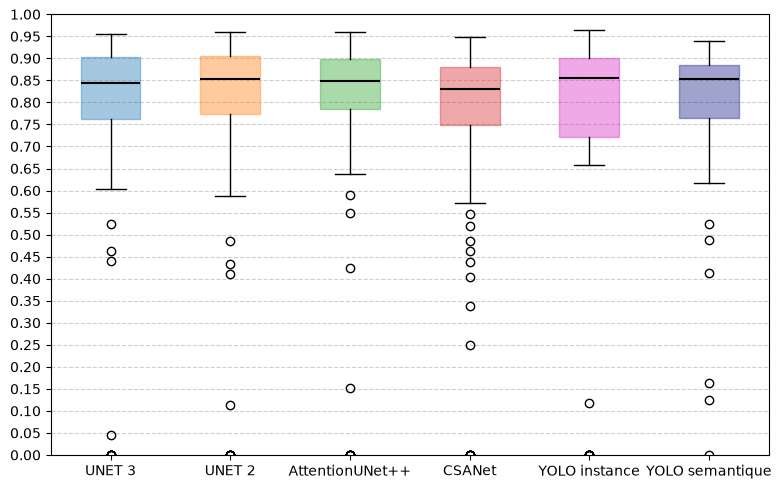

In [11]:
data = [DICE_UNET_3classes_Gonade, DICE_UNET_2classes_Gonade, DICE_ATTENTION_UNET_2classes_Gonade, DICE_CSANet_3classes_Gonade, DICE_YOLO_instance_3classes_Gonade, DICE_YOLO_semantique_3classes_Gonade]
labels = ["UNET 3", "UNET 2", "AttentionUNet++", "CSANet", "YOLO instance", "YOLO semantique"]
colors = ["#1f77b4", "#ff7f0e", "#2ca02c", "#d62728", "#d629c1", "#121b82"]  # Bleu, Orange, Vert, Rouge
limite = np.arange(0.00, 1.01, 0.05)
plot_boxplot([data], [labels], colors, size=(8, 5), limite_echelle=limite)

In [12]:
# ------- Comparaison des moyennes ----
print(f"Dice moyen U-NEt : {np.mean(DICE_UNET_3classes_Gonade):.3f}")
#print(f"Dice moyen U-NEt test : {np.mean(DICE_UNET_3classes_test_Gonade):.3f}")
print(f"Dice moyen U-NEt 2 classes : {np.mean(DICE_UNET_2classes_Gonade):.3f}")
print(f"Dice moyen Attention U-NEt 2 classes : {np.mean(DICE_ATTENTION_UNET_2classes_Gonade):.3f}")
print(f"Dice moyen CSA-Net 3 classes : {np.mean(DICE_CSANet_3classes_Gonade):.3f}")
print(f"Dice moyen YOLO instance : {np.mean(DICE_YOLO_instance_3classes_Gonade):.3f}")
print(f"Dice moyen YOLO sémantique : {np.mean(DICE_YOLO_semantique_3classes_Gonade):.3f}")

Dice moyen U-NEt : 0.780
Dice moyen U-NEt 2 classes : 0.784
Dice moyen Attention U-NEt 2 classes : 0.782
Dice moyen CSA-Net 3 classes : 0.754
Dice moyen YOLO instance : 0.684
Dice moyen YOLO sémantique : 0.788


In [13]:
# -------------- Analyse outliers --------------------
# Récupère les images avec un DICE inférieur à 0.50
indices = [i for i,x in enumerate(DICE_UNET_3classes_Gonade) if x < 0.60 and x > 0.00]

print(f"Dice :{[DICE_UNET_3classes_Gonade[indice] for indice in indices]}")
print(f"Names : {[names_gonade[indice] for indice in indices]}")

# Récupère les images avec un DICE inférieur à 0.50
indices = [i for i,x in enumerate(DICE_UNET_2classes_Gonade) if x < 0.60 and x > 0.00]

print(f"Dice :{[DICE_UNET_2classes_Gonade[indice] for indice in indices]}")
print(f"Names : {[names_gonade[indice] for indice in indices]}")

# Récupère les images avec un DICE inférieur à 0.50
indices = [i for i,x in enumerate(DICE_ATTENTION_UNET_2classes_Gonade) if x < 0.60 and x > 0.20]

print(f"Dice :{[DICE_ATTENTION_UNET_2classes_Gonade[indice] for indice in indices]}")
print(f"Names : {[names_gonade[indice] for indice in indices]}")

Dice :[0.5251592993736267, 0.4396391212940216, 0.4629727900028229, 0.04527762159705162]
Names : ['0007102_09.42.49_427181_2024.jpg', '0004652_11.23.44_356868_2019.jpg', '0004655_11.24.32_356868_2019.jpg', '0007158_11.21.41_427305_2024.jpg']
Dice :[0.5875190496444702, 0.48588624596595764, 0.43303510546684265, 0.41016653180122375, 0.11370083689689636]
Names : ['0004665_11.58.41_356918_2019.jpg', '0005928_11.37.06_405826_2022.jpg', '0004652_11.23.44_356868_2019.jpg', '0004655_11.24.32_356868_2019.jpg', '0007158_11.21.41_427305_2024.jpg']
Dice :[0.5900701284408569, 0.5491397976875305, 0.4241531789302826]
Names : ['0005958_13.58.11_405924_2022.jpg', '0006122_14.01.01_406320_2022.jpg', '0004652_11.23.44_356868_2019.jpg']


### Boxplots Dice des oeufs

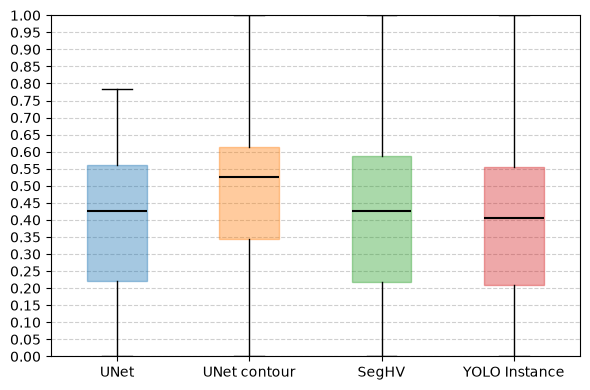

In [14]:
data = [DICE_UNET_oeufs, DICE_UNET_oeufs_contour, DICE_SegHV_oeufs, DICE_YOLO_instance_oeufs]
labels = ["UNet", "UNet contour", "SegHV", "YOLO Instance"]
colors = ["#1f77b4", "#ff7f0e", "#2ca02c", "#d62728", "#d629c1", "#121b82"]  # Bleu, Orange, Vert, Rouge
limite = np.arange(0.00, 1.01, 0.05)
plot_boxplot([data], [labels], colors, size=(6, 4), limite_echelle=limite)

In [26]:
# --- Comparaison des moyennes pour les oeufs ---
print(f"Dice moyen U-NEt : {np.mean(DICE_UNET_oeufs):.3f} (std : {np.std(DICE_UNET_oeufs):.3f})")
print(f"Dice moyen U-NEt contour: {np.mean(DICE_UNET_oeufs_contour):.3f} (std : {np.std(DICE_UNET_oeufs_contour):.3f})")
print(f"Dice moyen SegHV : {np.mean(DICE_SegHV_oeufs):.3f} (std : {np.std(DICE_SegHV_oeufs):.3f})")
print(f"Dice moyen YOLO instance : {np.mean(DICE_YOLO_instance_oeufs):.3f} (std : {np.std(DICE_YOLO_instance_oeufs):.3f})")

Dice moyen U-NEt : 0.383 (std : 0.237)
Dice moyen U-NEt contour: 0.465 (std : 0.253)
Dice moyen SegHV : 0.403 (std : 0.255)
Dice moyen YOLO instance : 0.369 (std : 0.249)


### Test de différences de moyennes entre les modèles

In [16]:
print("--- Test de Welch ---")
print(st.ttest_ind(DICE_UNET_3classes_Gonade, DICE_UNET_2classes_Gonade, equal_var=False)) # Désactive l'hypo des variances égales

print("\n--- Test de Wilcoxon-Mann-Whitney ---")
print(st.mannwhitneyu(DICE_UNET_3classes_Gonade, DICE_UNET_2classes_Gonade, alternative='two-sided')) # Dans les deux sens : A > B ou A < B

--- Test de Welch ---
TtestResult(statistic=np.float64(-0.1477500278593207), pvalue=np.float64(0.8826479274301223), df=np.float64(275.9994007714156))

--- Test de Wilcoxon-Mann-Whitney ---
MannwhitneyuResult(statistic=np.float64(9411.0), pvalue=np.float64(0.7102298057853497))


### Boxplots Diff surface des gonades

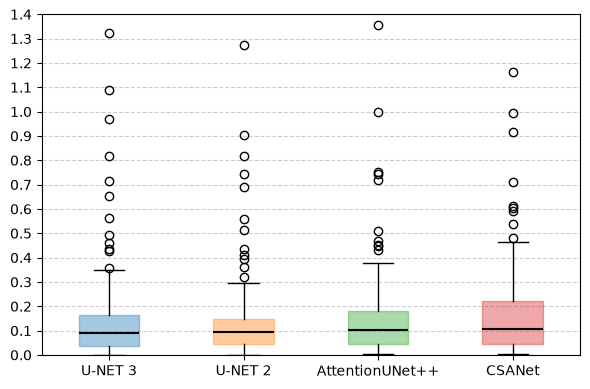

In [17]:
data = [
    Diff_UNET_3classes,
    Diff_UNET_2classes,
    Diff_ATTENTION_UNET_2classes,
    Diff_CSANet_3classes
]

data_clean = []

for x in data:
    x = np.array(x, dtype=float)
    x = x[np.isfinite(x)]  # enlève NaN et inf
    data_clean.append(x)

labels = ["U-NET 3", "U-NET 2", "AttentionUNet++", "CSANet"]
colors = ["#1f77b4", "#ff7f0e", "#2ca02c", "#d62728", "#d629c1", "#121b82"]  # Bleu, Orange, Vert, Rouge
limite = np.arange(0, 1.5, 0.1)
plot_boxplot([data_clean], [labels], colors, size=(6, 4), limite_echelle=limite)

### Boxplots Diff surface médiane des oeufs : prédit vs annotation

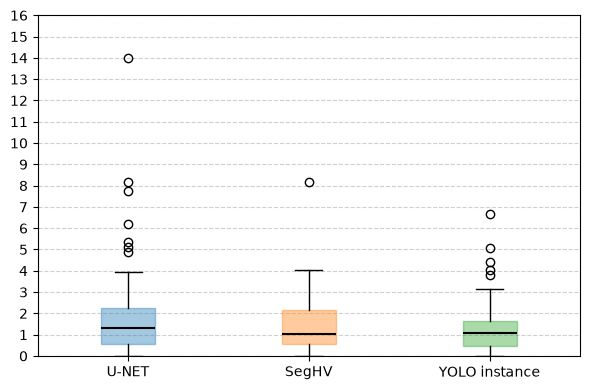

In [25]:
data = [
    Diff_UNET_oeufs,
    Diff_SegHV_oeufs,
    Diff_YOLO_instance_oeufs,
]

data_clean = []

for x in data:
    x = np.array(x, dtype=float)
    x = x[np.isfinite(x)]  # enlève NaN et inf
    data_clean.append(x)

labels = ["U-NET",  "SegHV", "YOLO instance",]
colors = ["#1f77b4", "#ff7f0e", "#2ca02c", "#d62728", "#d629c1", "#121b82"]  # Bleu, Orange, Vert, Rouge
limite = np.arange(0, 17, 1)
plot_boxplot([data_clean], [labels], colors, size=(6, 4), limite_echelle=limite)

## Résultats d'un modèle spécifique

### Sélection du modèle

In [51]:
modele = results_UNET_3classes
Dice_results = DICE_UNET_3classes_Gonade

### Récupération des catégories

In [52]:
categories = collect_all_folds(modele, "category")
positions = collect_all_folds(modele, "ops")
positions_ratio = collect_all_folds(modele, "ops_ratio")
diff_surfaces = collect_all_folds(modele, "diff_surf")

### Boxplots Dice selon les catégories

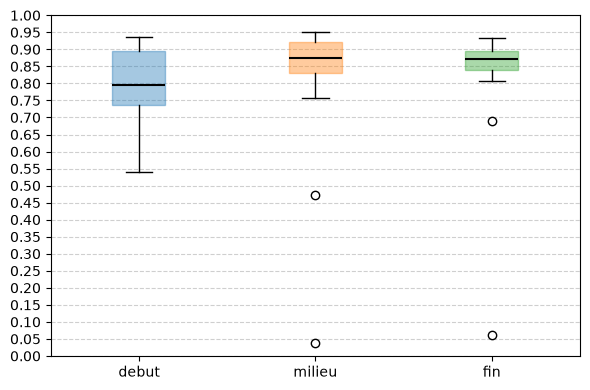

In [53]:
dice_by_category = {}

for category, dice in zip(categories, Dice_results):
    if category not in dice_by_category:
        dice_by_category[category] = []

    dice_by_category[category].append(dice)

labels = list(dice_by_category.keys())
data = [dice_by_category[category] for category in labels]

plot_boxplot(
    datasets=[data],
    labels=[labels],
    size = (6,4),
    colors=["#1f77b4", "#ff7f0e", "#2ca02c" ]
)

In [54]:
# Test de comparaison des moyennes par catégorie
print(st.ttest_ind(data[0], data[2], equal_var=False))

# Test de l'ANOVA
print(st.f_oneway(data[0], data[1], data[2])) #Significatif à 5%

TtestResult(statistic=np.float64(-0.6251349717473782), pvalue=np.float64(0.5361599935929946), df=np.float64(33.168322223416006))
F_onewayResult(statistic=np.float64(0.31496288006776807), pvalue=np.float64(0.7308906102606672))


### Boxplots Dice selon les positions

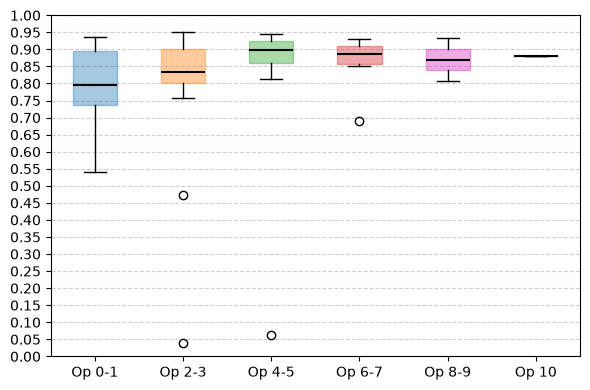

In [55]:
dice_by_position = {}

for position, dice in zip(positions, Dice_results):

    # Regroupement par paires : 0-1, 2-3, 4-5, ...
    group_start = (position // 2) * 2

    if group_start not in dice_by_position:
        dice_by_position[group_start] = []

    dice_by_position[group_start].append(dice)

labels = sorted(dice_by_position.keys())

display_labels = [
    f"Op {position}-{position + 1}" if position < 10 else "Op 10"
    for position in labels
]

data = [dice_by_position[position] for position in labels]

plot_boxplot(
    datasets=[data],
    labels=[display_labels],
    size=(6, 4),
    colors=[
        "#1f77b4", "#ff7f0e", "#2ca02c",
        "#d62728", "#d629c1", "#121b82"
    ]
)

### Boxplots Dice selon les positions ratios

In [31]:
dice_by_position_ratio = {}

for position_ratio, dice in zip(positions_ratio, Dice_results):

    # Regroupement par tranches de 10 %
    group_start = min(int(position_ratio * 10), 9) * 10

    if group_start not in dice_by_position_ratio:
        dice_by_position_ratio[group_start] = []

    dice_by_position_ratio[group_start].append(dice)

labels = sorted(dice_by_position_ratio.keys())

display_labels = [
    f"{position}-{position + 10}%"
    for position in labels
]

data = [dice_by_position_ratio[position] for position in labels]

plot_boxplot(
    datasets=[data],
    labels=[display_labels],
    size=(7, 4),
    colors=[
        "#1f77b4", "#ff7f0e", "#2ca02c",
        "#d62728", "#d629c1", "#121b82",
        "#ff00ff", "green", "orange", "purple"
    ]
)

NameError: name 'positions_ratio' is not defined

# Résultats sur l'échantillon de test

In [ ]:
# U-Net 3 classes
with open('../UNet/saves/Global/results_test_UNet_3classes_BCE_Dice.pkl', 'rb') as f:
    results_UNET_3classes = pickle.load(f)


FileNotFoundError: [Errno 2] No such file or directory: '../U-NET/saves/categories_test.pkl'

### Distribution des IoU

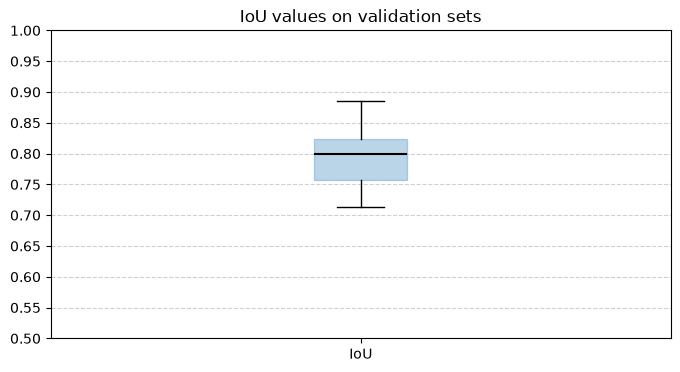

In [65]:
data = [all_iou_test]
labels = ["IoU"]
colors = ["#1f77b4"]  # Bleu, Orange, Vert, Rouge, rose, violet
size = (8,4)
create_boxplot(data, labels, colors, size=size, limite_echelle=np.arange(0.5, 1.01, 0.05))

### Boxplots par catégories

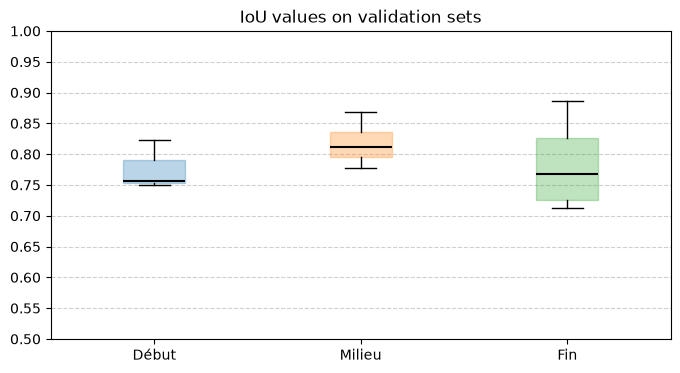

In [52]:
data = [all_iou_debut_test, all_iou_milieu_test, all_iou_fin_test]
labels = ["Début", "Milieu", "Fin"]
colors = ["#1f77b4", "#ff7f0e", "#2ca02c" ]  # Bleu, Orange, Vert, Rouge, rose, violet
size = (8,4)
create_boxplot(data, labels, colors, size=size, limite_echelle=np.arange(0.5, 1.01, 0.05))

In [67]:
# Test de l'ANOVA
print(st.f_oneway(all_iou_debut_test, all_iou_milieu_test, all_iou_fin_test)) # Pas de différences significatives de la moyenne

# Test de Levene pour vérifier l'hypothèse des variances égales
print(st.levene(all_iou_debut_test, all_iou_milieu_test, all_iou_fin_test))

F_onewayResult(statistic=np.float64(0.7752877770136098), pvalue=np.float64(0.4863869048687699))
LeveneResult(statistic=np.float64(2.206851919887238), pvalue=np.float64(0.16073928362260426))


# Analyse par images

Cette section compare, pour une image donnée, les métriques de segmentation de la gonade obtenues par les différents modèles 3 classes.

In [32]:
import pandas as pd
from pathlib import Path


def extraire_metriques_image(results, nom_image, classe="Gonade"):
    """Extrait les métriques d'une image depuis des résultats U-Net ou YOLO."""
    nom_recherche = Path(nom_image).name

    for fold_results in results.values():
        # Format U-Net : un dictionnaire de listes par fold
        if isinstance(fold_results, dict):
            noms = fold_results.get("name", [])
            for index, nom in enumerate(noms):
                if Path(nom).name == nom_recherche:
                    return {
                        "Dice": fold_results["dice_by_class"][classe][index],
                        "IoU": fold_results["iou_by_class"][classe][index],
                        "Précision": fold_results["precision_by_class"][classe][index],
                        "Rappel": fold_results["recall_by_class"][classe][index],
                        "Différence de surface": fold_results["diff_surface"][classe][index],
                    }

        # Format YOLO : une liste de résultats individuels par fold
        else:
            for image_results in fold_results:
                if Path(image_results["image"]).name == nom_recherche:
                    metriques = image_results["metrics"][classe]
                    return {
                        "Dice": metriques["dice"],
                        "IoU": metriques["iou"],
                        "Précision": metriques["precision"],
                        "Rappel": metriques["recall"],
                        "Différence de surface": metriques["diff_surface"],
                    }

    raise ValueError(
        f"L'image '{nom_image}' est introuvable dans les résultats de ce modèle. "
        "Utilisez le nom d'une image du jeu de validation 3 classes."
    )


def comparer_modeles_pour_image(nom_image):
    modeles = {
        "U-Net": results_UNET_3classes,
        "U-Net 2 classes": results_UNET_2classes,
        "AttentionUNet" : results_AttentionUNet_2classes,
        "YOLO Instance": results_YOLO_instance_3classes,
        "YOLO Sémantique": results_DA_YOLO_semantique_3classes,
    }

    lignes = {
        nom_modele: extraire_metriques_image(resultats, nom_image)
        for nom_modele, resultats in modeles.items()
    }

    return pd.DataFrame.from_dict(lignes, orient="index").rename_axis("Modèle").round(3)

### Sélection de l'image

Modifier la valeur de `nom_image`, puis exécuter la cellule pour afficher la comparaison.

In [33]:
nom_image = "0007102_09.42.49_427181_2024.jpg"
comparer_modeles_pour_image(nom_image)

,Dice,IoU,Précision,Rappel,Différence de surface
Modèle,,,,,
U-Net,0.525,0.356,0.991,0.357,0.971
U-Net 2 classes,0.766,0.621,0.963,0.637,0.514
AttentionUNet,0.800,0.667,0.979,0.677,0.468
YOLO Instance,0.921,0.853,0.984,0.866,0.334
YOLO Sémantique,0.899,0.817,0.998,0.818,0.503
